# 01- Data Acquisition: Bitcoin Historical Data
## Project: Crypto Market Detection using HMM

this notebook has de goal to download, explore an prepare the par (BTC-USD) historical
price data that will be used to detect market regimes using a hidden Markov model.

**Data source:** Yahoo Finance via *import* 'yfinance' API

### 1.1 Data Download

Daily OHLCV from 2018 to present

In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual Configuration
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14,6)

# Data from history of bitcoin price
btc = yf.download('BTC-USD',start='2018-01-01')
btc.to_csv('../data/raw/btc_usd_raw.csv')

# Data Recolected: OHLCV
print("Dimensions: ",btc.shape)
print("\nColumns: ", btc.columns.tolist())
btc.head()

[*********************100%***********************]  1 of 1 completed

Dimensions:  (2986, 5)

Columns:  [('Close', 'BTC-USD'), ('High', 'BTC-USD'), ('Low', 'BTC-USD'), ('Open', 'BTC-USD'), ('Volume', 'BTC-USD')]


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072


### 1.2 Initial Exploration

In [6]:
# Dataset Struct
print("Shape: ", btc.shape)
print("\nData types: ")
print(btc.dtypes)
print("\nNull values: ")
print(btc.isnull().sum())
print("\nDescriptive Stadistics:")
btc.describe()


Shape:  (2986, 5)

Data types: 
Price   Ticker 
Close   BTC-USD    float64
High    BTC-USD    float64
Low     BTC-USD    float64
Open    BTC-USD    float64
Volume  BTC-USD      int64
dtype: object

Null values: 
Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64

Descriptive Stadistics:


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
count,2986.000000,2986.000000,2986.000000,2986.000000,2.986000e+03
mean,38176.196520,38909.792207,37350.654351,38157.826608,3.055296e+10
std,32487.659523,33009.189126,31915.279893,32484.974871,2.208412e+10
min,3236.761719,3275.377930,3191.303467,3236.274658,2.923670e+09
25%,9552.001221,9725.413574,9369.246826,9552.409424,1.545165e+10
50%,28064.893555,28510.822266,27419.980469,28040.284180,2.634987e+10
75%,59117.727539,60621.265625,57805.007812,59114.658203,4.028809e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


**Note:** we can see exactly what we expect.The std shows us enormous volatility of $32,487, demonstrating why it is interesting to apply an HMM.
The median is lower than the mean, which shows a negative bias, with very long periods of time pushing the mean upwards.

### 1.3 Price History Visualization

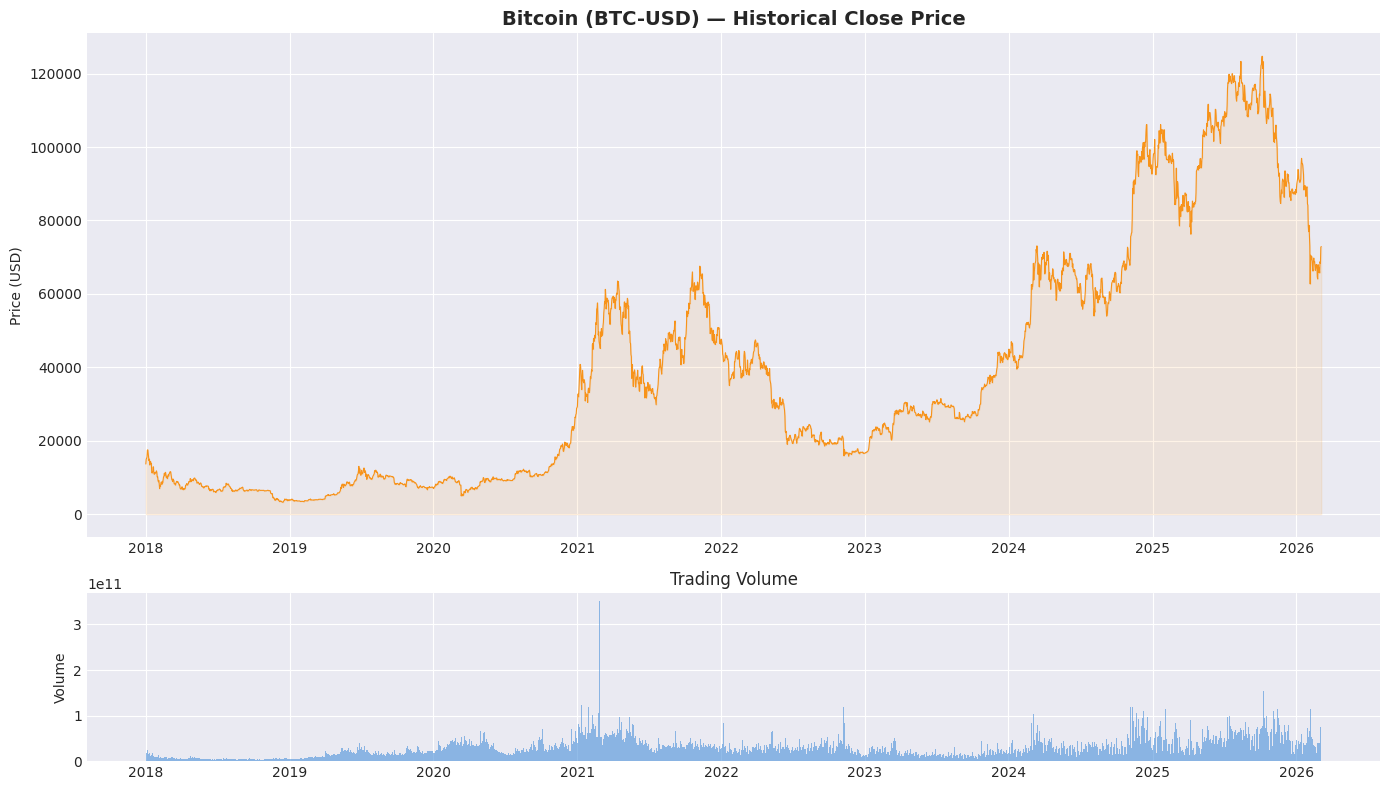

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 1]})

# Precio de cierre
axes[0].plot(btc.index, btc['Close'], color='#F7931A', linewidth=0.8)
axes[0].set_title('Bitcoin (BTC-USD) — Historical Close Price', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].fill_between(btc.index, btc['Close'].values.flatten(), alpha=0.1, color='#F7931A')

# Volumen
axes[1].bar(btc.index, btc['Volume'].values.flatten(), color='#4A90D9', alpha=0.6, width=1)
axes[1].set_title('Trading Volume', fontsize=12)
axes[1].set_ylabel('Volume')

plt.tight_layout()
plt.savefig('../results/figures/btc_price_history.png', dpi=150, bbox_inches='tight')
plt.show()